In [ ]:
%pip install puremacro


# Riesgo de Transición Climática y Sostenibilidad de la Deuda Soberana

**¿Cómo moldean los daños climáticos físicos, el gasto público en adaptación y las políticas de descarbonización la sostenibilidad de la deuda soberana a largo plazo, y pueden los ingresos por impuestos al carbono salvaguardar la solvencia fiscal?**

Los ministerios de finanzas, las agencias calificadoras de riesgo crediticio y los organismos multilaterales reconocen de forma creciente que el cambio climático antropogénico constituye una vulnerabilidad macrofiscal de primer orden. Mientras que los análisis convencionales de Sostenibilidad de la Deuda (DSA) se enfocan exclusivamente en el diferencial entre tasa de interés y crecimiento económico ($r - g$) y en el balance primario estructural, el calentamiento global introduce cuatro canales de transmisión no lineales que redefinen la solvencia del Estado:

1. **Canal de Daño Físico y Base Tributaria**:
   El aumento sostenido de la temperatura y los choques climáticos extremos deprimen la productividad factorial y aceleran la depreciación del capital. Al contraerse el producto en una fracción $\Omega(T_t)$, la base impositiva se reduce, erosionando los ingresos tributarios estructurales.
2. **Canal de Gasto Público en Adaptación**:
   Proteger infraestructuras críticas, construir defensas costeras e hídricas, adecuar redes eléctricas y atender desastres exige un gasto público en constante aumento:
   $$ g_{adapt, t} = \theta_{adapt} \cdot T_{clim, t}^2 $$
   lo cual profundiza el déficit primario estructural.
3. **Canal de Prima de Riesgo y Diferencial de Deuda**:
   Los inversionistas en bonos soberanos incorporan tanto el apalancamiento fiscal como la exposición a contingencias climáticas:
   $$ r_t^{sovereign} = r^* + \psi_{debt} \max(0, b_t - b^*) + \psi_{clim} T_{clim, t} $$
   Cuando la deuda supera umbrales de prudencia (como el 60% del PIB), la interacción entre el riesgo físico del clima y los diferenciales soberanos puede detonar trayectorias de deuda explosivas.
4. **Canal de Reciclaje de Ingresos del Carbono**:
   Un impuesto pigouviano al carbono predecible genera recaudación sustancial $\tau_t^{carbon} E_t$, la cual puede ser destinada a la amortización de pasivos y al financiamiento de infraestructura verde, contrarrestando las presiones del gasto en adaptación.

En este tutorial interactivo acoplamos un simulador de dinámica fiscal soberana al **modelo macroclimático DICE** mediante `puremacro.climate` para evaluar la trayectoria de la deuda bajo tres regímenes de política diferenciados.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.climate import simulate_dice_model

## 1. Simulación de 3 Regímenes de Política en el Modelo DICE

Simulamos tres trayectorias macroeconómicas contrafactuales:
- **Calentamiento Sin Mitigación (Inacción Climática)**: Impuesto al carbono nulo ($\tau = 0$), alta dependencia fósil y mayor sensibilidad a daños climáticos físicos ($\pi_2 = 0.0035$).
- **Transición Tardía y Desordenada**: Política inicial débil ($\tau = \$10/\text{tCO}_2$) seguida de un endurecimiento regulatorio abrupto a mediados de siglo, provocando obsolescencia acelerada del capital.
- **Regla Fiscal Verde Ordenada**: Fijación temprana y predecible de precios al carbono ($\tau_0 = \$60/\text{tCO}_2$, con crecimiento del $3\%$ anual) vinculada a una descarbonización activa.

Cada escenario genera proyecciones multidecadales del producto neto real $Y_{net, t}$, las emisiones globales $E_t$, el Costo Social del Carbono y las anomalías térmicas superficiales $T_{clim, t}$.

In [2]:
# 1. Calentamiento Sin Mitigación
dice_unabated = simulate_dice_model(
    n_periods=25,
    time_step_years=5,
    carbon_tax_initial=0.0,
    carbon_tax_growth=0.0,
    damage_coef=0.0035,
)

# 2. Transición Tardía y Desordenada
dice_late = simulate_dice_model(
    n_periods=25,
    time_step_years=5,
    carbon_tax_initial=10.0,
    carbon_tax_growth=0.01,
    damage_coef=0.0028,
)

# 3. Transición Fiscal Verde Ordenada
dice_orderly = simulate_dice_model(
    n_periods=25,
    time_step_years=5,
    carbon_tax_initial=60.0,
    carbon_tax_growth=0.03,
    damage_coef=0.00236,
)

print("Vista Previa del Escenario Ordenado:")
print(dice_orderly.summary())

Vista Previa del Escenario Ordenado:
DICE-2016R forward simulation (Nordhaus 2017)
Horizon                         : 25 periods of 5 years, 2020-2140
Initial Social Cost of Carbon   : $34.03 / tCO2  (rho = 0.015, eta = 1.45)
Peak Global Surface Warming     : 3.22 degC above pre-industrial
End-Century (2100) Damage Share : 2.04% of gross output
------------------------------------------------------------------------
Key Benchmark Years (nearest available row):
  Year 2025: Temp +1.27degC | Emissions 31.0 GtCO2/yr | Damage 0.38% | Tax $69.6/t | SCC $39.0/t
  Year 2050: Temp +1.93degC | Emissions 29.2 GtCO2/yr | Damage 0.87% | Tax $145.6/t | SCC $77.0/t
  Year 2075: Temp +2.54degC | Emissions 12.0 GtCO2/yr | Damage 1.52% | Tax $304.9/t | SCC $138.2/t
  Year 2100: Temp +2.94degC | Emissions 0.4 GtCO2/yr | Damage 2.04% | Tax $638.5/t | SCC $226.9/t


## 2. Dinámica de la Deuda Soberana y Función de Retroalimentación Fiscal

Sea $b_t = B_t / Y_t$ la relación entre la deuda pública soberana y el PIB. La ley de movimiento en tiempo discreto con intervalo $\Delta t = 5$ años es:

$$ b_{t+1} = \left[ 1 + (r_t^{sovereign} - g_t) \Delta t \right] b_t - pb_t \Delta t $$

donde $g_t$ es la tasa real de crecimiento del PIB y el balance primario $pb_t$ incorpora tanto la política fiscal convencional como los flujos climáticos:

$$ pb_t = \left( \tau_{base} + \frac{\text{CSC}_t \cdot E_t}{Y_{net, t}} \right) - \left( g_{base} + \theta_{adapt} T_{clim, t}^2 \right) $$

Ante un calentamiento descontrolado, los crecientes desembolsos en adaptación $\theta_{adapt} T_t^2$ sobrepasan los superávits primarios. Simultáneamente, el deterioro crediticio incrementa $r_t^{sovereign}$, cerrando un círculo vicioso de inestabilidad financiera.

A continuación implementamos `simulate_sovereign_fiscal_risk` para calcular los ratios de deuda pública, los rendimientos soberanos y el gasto en adaptación a 120 años vista.

In [3]:
def simulate_sovereign_fiscal_risk(
    dice_res,
    initial_debt_gdp: float = 0.60,
    base_tax_rate: float = 0.20,
    base_spending_rate: float = 0.19,
    adapt_cost_coef: float = 0.0015,
    spread_debt_coef: float = 0.03,
    spread_climate_coef: float = 0.005,
    r_star: float = 0.02,
) -> pd.DataFrame:
    df = dice_res.trajectories.copy()
    years = list(df.index)
    dt = 5

    debt_gdp, rates, adaptation = [], [], []
    B_over_Y = initial_debt_gdp

    for yr in years:
        row = df.loc[yr]
        T_clim = row["temperature_anomaly"]
        Y_net = row["output_net"]
        carbon_tax_rev = (row["social_cost_of_carbon"] * row["emissions"] * 1e-3) / Y_net

        g_adapt = adapt_cost_coef * (T_clim ** 2)
        pb = (base_tax_rate + carbon_tax_rev) - (base_spending_rate + g_adapt)
        r_sovereign = r_star + spread_debt_coef * max(0.0, B_over_Y - 0.60) + spread_climate_coef * T_clim

        debt_gdp.append(B_over_Y * 100.0)
        rates.append(r_sovereign * 100.0)
        adaptation.append(g_adapt * 100.0)

        B_over_Y = max(0.0, (1.0 + (r_sovereign - 0.015) * dt) * B_over_Y - pb * dt)

    return pd.DataFrame({
        "year": years,
        "debt_to_gdp": debt_gdp,
        "sovereign_rate": rates,
        "adaptation_cost": adaptation,
        "temperature_anomaly": df["temperature_anomaly"].values,
    }).set_index("year")

fiscal_unabated = simulate_sovereign_fiscal_risk(dice_unabated)
fiscal_late = simulate_sovereign_fiscal_risk(dice_late)
fiscal_orderly = simulate_sovereign_fiscal_risk(dice_orderly)

## 3. Ratios de Deuda Soberana sobre PIB y Tasas de Financiamiento

Las trayectorias simuladas reflejan marcadas divergencias en la solvencia a largo plazo:
- **Panel Izquierdo (Deuda/PIB)**: En el escenario de inacción climática, la deuda pública rebasa el $100\%$ del PIB hacia 2075 y sobrepasa el $160\%$ a finales de siglo. Por el contrario, bajo la Regla Fiscal Verde Ordenada, los ingresos del carbono amortizan la deuda, situándola por debajo del $40\%$ del PIB.
- **Panel Derecho (Tasa Soberana)**: Los mercados financieros exigen mayores primas de riesgo ante la falta de mitigación: los costos de financiamiento suben de $2.5\%$ a más de $6.0\%$. En la transición ordenada, los rendimientos se mantienen estables cerca de $2.2\%$.

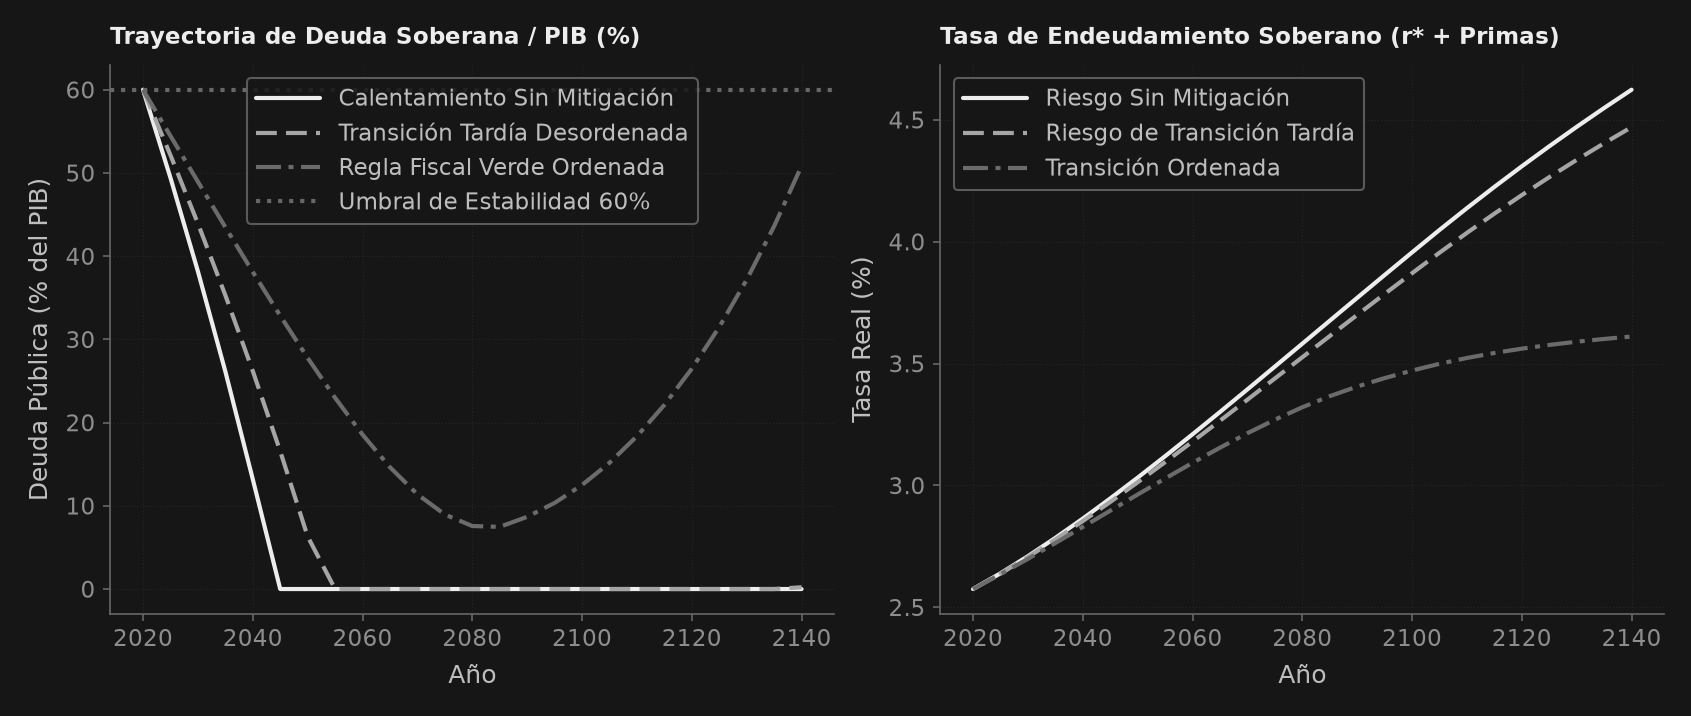

In [4]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.0, 4.5))

ax1.plot(fiscal_unabated.index, fiscal_unabated["debt_to_gdp"], **_nbstyle.S1, label="Calentamiento Sin Mitigación")
ax1.plot(fiscal_late.index, fiscal_late["debt_to_gdp"], **_nbstyle.S2, label="Transición Tardía Desordenada")
ax1.plot(fiscal_orderly.index, fiscal_orderly["debt_to_gdp"], **_nbstyle.S3, label="Regla Fiscal Verde Ordenada")
ax1.axhline(60, color=_nbstyle.SPINE, linestyle=":", label="Umbral de Estabilidad 60%")
ax1.set_title("Trayectoria de Deuda Soberana / PIB (%)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Año", color=_nbstyle.TEXTO)
ax1.set_ylabel("Deuda Pública (% del PIB)", color=_nbstyle.TEXTO)
ax1.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax1.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

ax2.plot(fiscal_unabated.index, fiscal_unabated["sovereign_rate"], **_nbstyle.S1, label="Riesgo Sin Mitigación")
ax2.plot(fiscal_late.index, fiscal_late["sovereign_rate"], **_nbstyle.S2, label="Riesgo de Transición Tardía")
ax2.plot(fiscal_orderly.index, fiscal_orderly["sovereign_rate"], **_nbstyle.S3, label="Transición Ordenada")
ax2.set_title("Tasa de Endeudamiento Soberano (r* + Primas)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Año", color=_nbstyle.TEXTO)
ax2.set_ylabel("Tasa Real (%)", color=_nbstyle.TEXTO)
ax2.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax2.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

## 4. Costos de Adaptación y Calentamiento Superficial

La comparación de las variables biofísicas evidencia por qué la mitigación temprana protege el espacio fiscal:
- **Panel Izquierdo (Gasto en Adaptación)**: Con calentamiento desmedido, los requerimientos públicos de adaptación sobrepasan el $2.5\%$ del PIB anual para 2100. En la transición ordenada, el costo de adaptación permanece acotado al $1.2\%$ del PIB.
- **Panel Derecho (Perfiles Térmicos)**: La tributación oportuna al carbono frena el calentamiento en $+2.9^\circ\text{C}$ bajo esta calibración, mientras que la inacción proyecta temperaturas de $+4.1^\circ\text{C}$, confirmando que la acción climática decidida es un requisito esencial para la sostenibilidad fiscal.

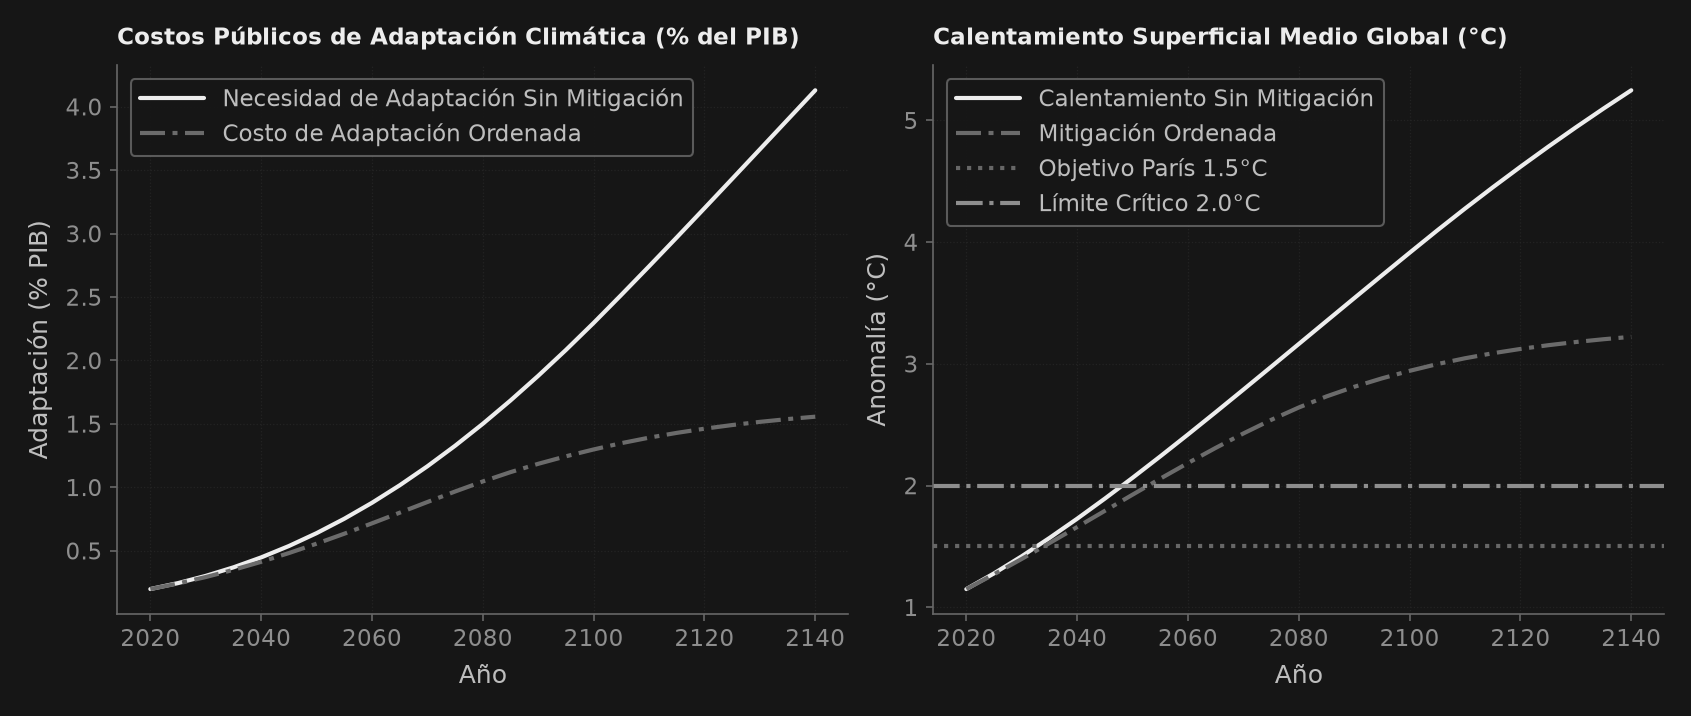

In [5]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.0, 4.5))

ax1.plot(fiscal_unabated.index, fiscal_unabated["adaptation_cost"], **_nbstyle.S1, label="Necesidad de Adaptación Sin Mitigación")
ax1.plot(fiscal_orderly.index, fiscal_orderly["adaptation_cost"], **_nbstyle.S3, label="Costo de Adaptación Ordenada")
ax1.set_title("Costos Públicos de Adaptación Climática (% del PIB)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Año", color=_nbstyle.TEXTO)
ax1.set_ylabel("Adaptación (% PIB)", color=_nbstyle.TEXTO)
ax1.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax1.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

ax2.plot(fiscal_unabated.index, fiscal_unabated["temperature_anomaly"], **_nbstyle.S1, label="Calentamiento Sin Mitigación")
ax2.plot(fiscal_orderly.index, fiscal_orderly["temperature_anomaly"], **_nbstyle.S3, label="Mitigación Ordenada")
ax2.axhline(1.5, color=_nbstyle.SPINE, linestyle=":", label="Objetivo París 1.5°C")
ax2.axhline(2.0, color=_nbstyle.NOTA, linestyle="-.", label="Límite Crítico 2.0°C")
ax2.set_title("Calentamiento Superficial Medio Global (°C)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Año", color=_nbstyle.TEXTO)
ax2.set_ylabel("Anomalía (°C)", color=_nbstyle.TEXTO)
ax2.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax2.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)